'''
Выполнил: Дмитрий Трифонов, 1 курс, 12-25РПм, Программная инженерия
Практикум 2.1 — Тензоры и операции (NumPy)
'''

## Цель работы
Изучить понятия тензоров, их формы и ранги, освоить операции индексации, срезов, reshape, transpose и broadcasting в NumPy, а также сравнить производительность наивных циклов и векторизованных операций. Выполнить простую обработку изображения.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)  # для воспроизводимости

## Задание 1: Создание тензоров и их свойства

In [2]:
x = np.array(12)
v = np.array([1, 2, 3])
M = np.array([[1, 2, 3],[4, 5, 6]])
T = np.random.randn(2, 3, 4)
print('Ранги (ndim):', x.ndim, v.ndim, M.ndim, T.ndim)
print('Формы: M:', M.shape, 'T:', T.shape)
print('Тип данных T:', T.dtype)

Ранги (ndim): 0 1 2 3
Формы: M: (2, 3) T: (2, 3, 4)
Тип данных T: float64


## Задание 2: Индексация, срезы, reshape и transpose

In [3]:
A = np.arange(24).reshape(4, 6)
print('Матрица A:\n', A)
slice_A = A[:2, 3:]
print('\nСрез (верхние 2 строки, последние 3 столбца):\n', slice_A)
B = A.reshape(6, 4)
C = A.T
print('\nB.shape =', B.shape)
print('C.shape =', C.shape)

Матрица A:
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]

Срез (верхние 2 строки, последние 3 столбца):
 [[ 3  4  5]
 [ 9 10 11]]

B.shape = (6, 4)
C.shape = (6, 4)


In [4]:
u = np.array([1, 2, 3, 4, 5, 6])
print('\nA + u (broadcasting):\n', A + u)


A + u (broadcasting):
 [[ 1  3  5  7  9 11]
 [ 7  9 11 13 15 17]
 [13 15 17 19 21 23]
 [19 21 23 25 27 29]]


## Задание 3: Векторизация vs наивные циклы

In [5]:
def naive_add(x, y):
    assert x.shape == y.shape
    z = np.empty_like(x)
    for i in range(x.shape[0]):
        z[i] = x[i] + y[i]
    return z

def naive_relu(x):
    z = np.empty_like(x)
    for i in range(x.shape[0]):
        z[i] = x[i] if x[i] > 0 else 0
    return z

def naive_matrix_vector_dot(M, v):
    assert M.shape[1] == v.shape[0]
    res = np.zeros(M.shape[0])
    for i in range(M.shape[0]):
        s = 0.0
        for j in range(M.shape[1]):
            s += M[i, j] * v[j]
        res[i] = s
    return res

In [6]:
x = np.random.randn(100_000)
y = np.random.randn(100_000)
%timeit naive_add(x, y)
%timeit x + y

25.4 ms ± 622 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
43.2 μs ± 1.73 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [7]:
M = np.random.randn(1000, 1000)
v = np.random.randn(1000)
%timeit naive_matrix_vector_dot(M, v)
%timeit M.dot(v)

269 ms ± 6.64 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
241 μs ± 50.8 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Задание 4: Мини-проект — обработка изображения

In [8]:
img = np.random.randint(0, 255, size=(64, 64)).astype('float32')
img_norm = (img - img.mean()) / (img.std() + 1e-8)
img_01 = (img - img.min()) / (img.max() - img.min() + 1e-8)
img_boost = np.clip(img_01 * 1.5, 0, 1)
print('Форма:', img.shape)
print('Среднее после нормализации:', float(img_norm.mean()))
print('Std после нормализации:', float(img_norm.std()))

Форма: (64, 64)
Среднее после нормализации: -1.3969838619232178e-09
Std после нормализации: 1.0000001192092896


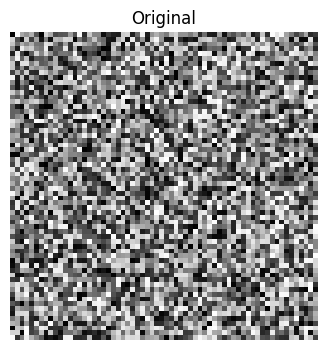

In [9]:
plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.show()

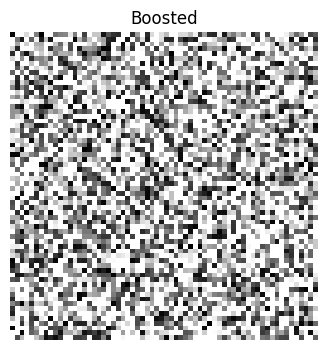

In [10]:
plt.figure(figsize=(4,4))
plt.imshow(img_boost, cmap='gray')
plt.title('Boosted')
plt.axis('off')
plt.show()

## Выводы
- Изучены тензоры различных рангов и их формы
- Освоены операции срезов, reshape, transpose и broadcasting
- Векторизация NumPy значительно быстрее наивных циклов
- Нормализация изображения улучшает числовую стабильность и визуальное восприятие
- Навыки применяются в машинном обучении, компьютерном зрении и анализе данных